# Задача 1

Пусть $X_1, X_2, \ldots, X_n$ — выборка из экспоненциального распределения с параметром $\lambda$. Найти оценку максимального правдоподобия параметра $\lambda$, сравнить ее с байесовской оценкой (MAP и математическое ожидание апостреорного распределения), подобрав сопряженное распределение. Сравнить полученные байесовские оценки с оценкой MLE. Найти предсказательное распределение

## Решение

### MLE оценка

Плотность экспоненциального распределения: $f(x \mid \lambda) = \lambda e^{-\lambda x}$ для $x \geq 0$.

Функция правдоподобия:
$$L(\lambda) = \prod_{i=1}^{n} \lambda e^{-\lambda x_i} = \lambda^n e^{-\lambda \sum x_i} = \lambda^n e^{-n\lambda\bar{X}}$$

где $\bar{X} = \frac{1}{n}\sum x_i$ - выборочное среднее.

Логарифмируем: $\ell(\lambda) = n\ln\lambda - n\lambda\bar{X}$.

Находим максимум: $\frac{d\ell}{d\lambda} = \frac{n}{\lambda} - n\bar{X} = 0$.

Откуда:
$$\hat{\lambda}_{MLE} = \frac{1}{\bar{X}}$$

### Байесовский вывод

**Сопряженное априорное:** Гамма-распределение
$$\pi(\lambda) = \frac{\beta^{\alpha}}{\Gamma(\alpha)} \lambda^{\alpha-1} e^{-\beta\lambda}$$

где $\alpha, \beta$ — гиперпараметры.

**Апост. распределение:**

Апост. плотность: $\pi(\lambda|\mathbf{x}) \propto L(\lambda) \cdot \pi(\lambda) = \lambda^{n+\alpha-1} e^{-\lambda(\sum x_i + \beta)}$

Это гамма-распределение с параметрами:
- $\alpha_{post} = n + \alpha$
- $\beta_{post} = n\bar{x} + \beta$

$$\lambda|\mathbf{x} \sim \text{Gamma}(\alpha_{post}, \beta_{post})$$


### MAP оценка

MAP — мода апост. распределения:
$$\hat{\lambda}_{MAP} = \frac{\alpha_{post} - 1}{\beta_{post}} = \frac{n + \alpha - 1}{n\bar{x} + \beta}$$

(при $\alpha \geq 1$)


### Предсказательное распределение

$$p(x_{n+1}|\mathbf{x}) = \int_0^{\infty} f(x_{n+1}|\lambda) \pi(\lambda|\mathbf{x}) d\lambda$$

После вычислений получаем:
$$p(x_{n+1}|\mathbf{x}) = \frac{\alpha_{post}}{\beta_{post}} \left(1 + \frac{x_{n+1}}{\beta_{post}}\right)^{-(\alpha_{post} + 1)}$$

Это распределение с параметрами:
- Масштаб: $\beta_{post} = n\bar{x} + \beta$
- Форма: $\alpha_{post} = n + \alpha$

**Замечание:** Предсказательное распределение имеет более тяжелые хвосты, чем экспоненциальное, что отражает неопределенность в параметре $\lambda$.


Генерируем выборку и вычисляем оценки: MLE, MAP и мат. ож. апост. распределения.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Параметры
n = 20
lambda_true = 2.0
a_prior = 2.0  # параметр формы
b_prior = 1.0  # параметр масштаба

# Генерируем выборку
np.random.seed(42)
X = np.random.exponential(scale=1/lambda_true, size=n)
x_bar = np.mean(X)

# Оценки
lambda_mle = 1 / x_bar
a_post = n + a_prior
b_post = b_prior + n * x_bar  # b + n*X_bar
lambda_map = (a_post - 1) / b_post if a_post > 1 else a_post / b_post
lambda_post_mean = a_post / b_post

print(f"Истинное λ: {lambda_true:.4f}")
print(f"MLE: {lambda_mle:.4f}")
print(f"MAP: {lambda_map:.4f}")
print(f"Posterior mean: {lambda_post_mean:.4f}")
print(f"a_post = {a_post}, b_post = {b_post:.4f}")

Истинное λ: 2.0000
MLE: 2.1931
MAP: 2.0752
Posterior mean: 2.1740
a_post = 22.0, b_post = 10.1195


Строим графики априорного, апост. и предсказательного распределений

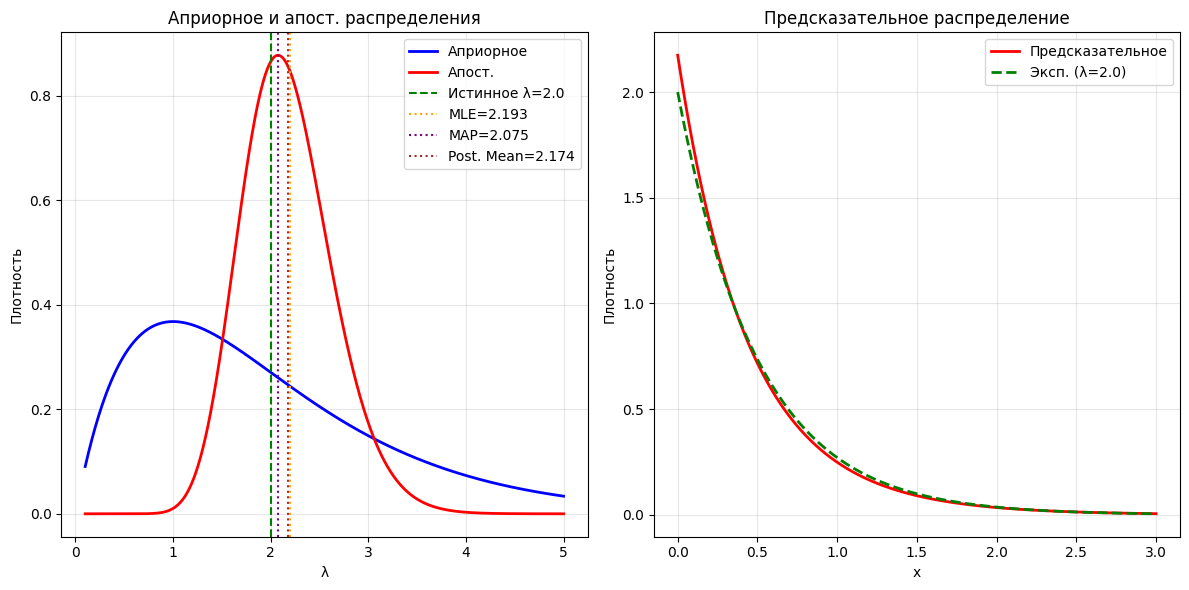

In [53]:
# Визуализация
lambda_range = np.linspace(0.1, 5, 1000)
prior = stats.gamma.pdf(lambda_range, a=a_prior, scale=1/b_prior)
posterior = stats.gamma.pdf(lambda_range, a=a_post, scale=1/b_post)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(lambda_range, prior, 'b-', linewidth=2, label='Априорное')
plt.plot(lambda_range, posterior, 'r-', linewidth=2, label='Апост.')
plt.axvline(lambda_true, color='g', linestyle='--', label=f'Истинное λ={lambda_true}')
plt.axvline(lambda_mle, color='orange', linestyle=':', label=f'MLE={lambda_mle:.3f}')
plt.axvline(lambda_map, color='purple', linestyle=':', label=f'MAP={lambda_map:.3f}')
plt.axvline(lambda_post_mean, color='brown', linestyle=':', label=f'Post. Mean={lambda_post_mean:.3f}')
plt.xlabel('λ')
plt.ylabel('Плотность')
plt.title('Априорное и апост. распределения')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
x_new_range = np.linspace(0, 3, 1000)
# Предсказательное распределение: (n+a)(b+n*X_bar)^(n+a) / (x_new + b + n*X_bar)^(n+a+1)
predictive = (a_post * (b_post**(a_post))) / ((x_new_range + b_post)**(a_post + 1))
exponential_true = lambda_true * np.exp(-lambda_true * x_new_range)

plt.plot(x_new_range, predictive, 'r-', linewidth=2, label='Предсказательное')
plt.plot(x_new_range, exponential_true, 'g--', linewidth=2, label=f'Эксп. (λ={lambda_true})')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Предсказательное распределение')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Апост. распределение более концентрированное, чем априорное. Предсказательное распределение имеет более тяжелые хвосты, чем экспоненциальное

# Задача 2

**Мультиномиальное распределение**

Пусть проводится серия из $n$ испытаний и в результате каждого испытания происходит ровно одно событие из набора $A_1, A_2, \dots, A_m$, причем вероятности этих событий равны соответственно $\mathsf{p}_1, \mathsf{p}_2, \dots, \mathsf{p}_m$, причем
$$\sum_{i=1}^{m}\mathsf{p}_i = 1.$$

Тогда совместное распределение величин $X_1, X_2, \dots, X_m$, где $X_k$ — число наступлений события $A_k$ в серии из $n$ испытаний, задается вероятностями

$$
\mathsf{P}\left(X_1 = n_1, \dots, X_m = n_m, \right) = \frac{n!}{n_1!\dots n_m!}\mathsf{p}_1^{n_1}\dots \mathsf{p}_m^{n_m},
$$

где $n_1, n_2, \dots, n_m$ — произвольный набор целых неотрицательных чисел, таких что

$$\sum_{i=1}^m n_i = n.$$

Произведите байесовский вывод для мультиномиального распределения: найдите апостериорное распределение, используя в качестве сопоряженного распределения к правдоподобию [распределение Дирихле](https://ru.wikipedia.org/wiki/%D0%A0%D0%B0%D1%81%D0%BF%D1%80%D0%B5%D0%B4%D0%B5%D0%BB%D0%B5%D0%BD%D0%B8%D0%B5_%D0%94%D0%B8%D1%80%D0%B8%D1%85%D0%BB%D0%B5), найдите предсказательное распределение. Объясните результат.

## Решение

### Правдоподобие

Пусть наблюдены данные $D = (n_1, n_2, \dots, n_m)$, где $n_k$ - число наступлений события $A_k$ в $n$ испытаниях.

Функция правдоподобия:
$$L(\mathbf{p} \mid D) = \frac{n!}{\prod_{k=1}^{m} n_k!} \prod_{k=1}^{m} p_k^{n_k}$$

где $\mathbf{p} = (p_1, p_2, \dots, p_m)$ - вектор вероятностей, $\sum p_k = 1$.

### Сопряженное априорное — распределение Дирихле

Плотность:
$$\pi(\mathbf{p}|\boldsymbol{\alpha}) = \frac{\Gamma(\sum \alpha_i)}{\prod \Gamma(\alpha_i)} \prod p_i^{\alpha_i - 1}$$

где $\boldsymbol{\alpha} = (\alpha_1, \ldots, \alpha_m)$ — гиперпараметры, $\alpha_i > 0$.

**Свойства:**
- $\mathbb{E}[p_i] = \frac{\alpha_i}{\sum \alpha_j}$
- При $\alpha_i = 1$ для всех $i$ — равномерный априор (неинформативный)


### Апост. распределение

Апост. плотность: $\pi(\mathbf{p}|\mathbf{n}, \boldsymbol{\alpha}) \propto \prod p_i^{n_i + \alpha_i - 1}$

Это распределение Дирихле с параметрами:
$$\alpha_i^{post} = n_i + \alpha_i, \quad i = 1, \ldots, m$$

$$\mathbf{p}|\mathbf{n}, \boldsymbol{\alpha} \sim \text{Dirichlet}(\boldsymbol{\alpha}^{post})$$

**Интерпретация:** Апост. параметры = наблюдения + априорные параметры


### Предсказательное распределение

Предсказательное распределение для нового наблюдения $x_{\text{new}} \in \{1, 2, \dots, m\}$ (индекс категории):
$$
p(x_{\text{new}} = k \mid D, \boldsymbol{\alpha}) = \int_{\Delta^{m-1}} p(x_{\text{new}} = k \mid \mathbf{p}) \cdot p(\mathbf{p} \mid D, \boldsymbol{\alpha}) d\mathbf{p}
$$

$$
= \int_{\Delta^{m-1}} p_k \cdot \frac{\Gamma(\alpha_0 + n)}{\prod_{j=1}^{m} \Gamma(\alpha_j + n_j)} \prod_{j=1}^{m} p_j^{\alpha_j + n_j - 1} d\mathbf{p}
$$

$$
= \frac{\Gamma(\alpha_0 + n)}{\prod_{j=1}^{m} \Gamma(\alpha_j + n_j)} \int_{\Delta^{m-1}} p_k \prod_{j=1}^{m} p_j^{\alpha_j + n_j - 1} d\mathbf{p}
$$

$$
= \frac{\Gamma(\alpha_0 + n)}{\prod_{j=1}^{m} \Gamma(\alpha_j + n_j)} \int_{\Delta^{m-1}} p_k^{(\alpha_k + n_k + 1) - 1} \prod_{j \neq k} p_j^{\alpha_j + n_j - 1} d\mathbf{p}
$$

Используя свойство интеграла Дирихле:
$$
\int_{\Delta^{m-1}} p_k^{(\alpha_k + n_k + 1) - 1} \prod_{j \neq k} p_j^{\alpha_j + n_j - 1} d\mathbf{p} = \frac{\Gamma(\alpha_k + n_k + 1) \prod_{j \neq k} \Gamma(\alpha_j + n_j)}{\Gamma(\alpha_0 + n + 1)}
$$

$$
= \frac{(\alpha_k + n_k) \Gamma(\alpha_k + n_k) \prod_{j \neq k} \Gamma(\alpha_j + n_j)}{\Gamma(\alpha_0 + n + 1)} = \frac{(\alpha_k + n_k) \prod_{j=1}^{m} \Gamma(\alpha_j + n_j)}{\Gamma(\alpha_0 + n + 1)}
$$

Таким образом:
$$
p(x_{\text{new}} = k \mid D, \boldsymbol{\alpha}) = \frac{\Gamma(\alpha_0 + n)}{\prod_{j=1}^{m} \Gamma(\alpha_j + n_j)} \cdot \frac{(\alpha_k + n_k) \prod_{j=1}^{m} \Gamma(\alpha_j + n_j)}{\Gamma(\alpha_0 + n + 1)}
$$

$$
= \frac{\alpha_k + n_k}{\alpha_0 + n}
$$

## Объяснение результата

**Апостериорное распределение:**
- Параметры Дирихле обновляются простым сложением: $\alpha_k' = \alpha_k + n_k$
- Априорные параметры $\alpha_k$ можно интерпретировать как "псевдонаблюдения" категории $k$
- Сумма параметров обновляется: $\alpha_0' = \alpha_0 + n$

**Предсказательное распределение:**
- Вероятность наблюдения категории $k$ равна $\frac{\alpha_k + n_k}{\alpha_0 + n}$
- Это взвешенное среднее между априорной вероятностью $\frac{\alpha_k}{\alpha_0}$ и эмпирической частотой $\frac{n_k}{n}$
- При $n \to \infty$ предсказательное распределение стремится к эмпирическим частотам
- При малых $n$ большее влияние оказывает априорное распределение

**Интерпретация параметров:**
- Если все $\alpha_k = 1$ (равномерный априор), то $p(x_{\text{new}} = k \mid D) = \frac{1 + n_k}{m + n}$ — сглаженная эмпирическая частота
- Если $\alpha_k = \alpha$ для всех $k$ (симметричный априор), то априорное распределение симметрично относительно всех категорий
- Чем больше $\alpha_0 = \sum \alpha_k$, тем "сильнее" априор и тем медленнее обновление при поступлении новых данных


Генерируем наблюдения и вычисляем апост. параметры и предсказательные вероятности.


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import dirichlet
import matplotlib.tri as tri

# Параметры
m = 3
n = 50
alpha_prior = np.array([2.0, 2.0, 2.0])

# Генерируем наблюдения
np.random.seed(42)
true_p = np.array([0.5, 0.3, 0.2])
n_obs = np.random.multinomial(n, true_p)

print("Истинные вероятности:", true_p)
print("Наблюдения:", n_obs)
print("Эмпирические частоты:", n_obs / n)

# Апост. параметры и оценки
alpha_post = n_obs + alpha_prior
alpha_0 = np.sum(alpha_prior)
posterior_mean = alpha_post / np.sum(alpha_post)
predictive = alpha_post / (alpha_0 + n)

print("\nАприорные параметры:", alpha_prior)
print("Апост. параметры:", alpha_post)
print("Апост. мат. ож.:", posterior_mean)
print("Предсказательные вероятности:", predictive)


Истинные вероятности: [0.5 0.3 0.2]
Наблюдения: [24 11 15]
Эмпирические частоты: [0.48 0.22 0.3 ]

Априорные параметры: [2. 2. 2.]
Апост. параметры: [26. 13. 17.]
Апост. мат. ож.: [0.46428571 0.23214286 0.30357143]
Предсказательные вероятности: [0.46428571 0.23214286 0.30357143]


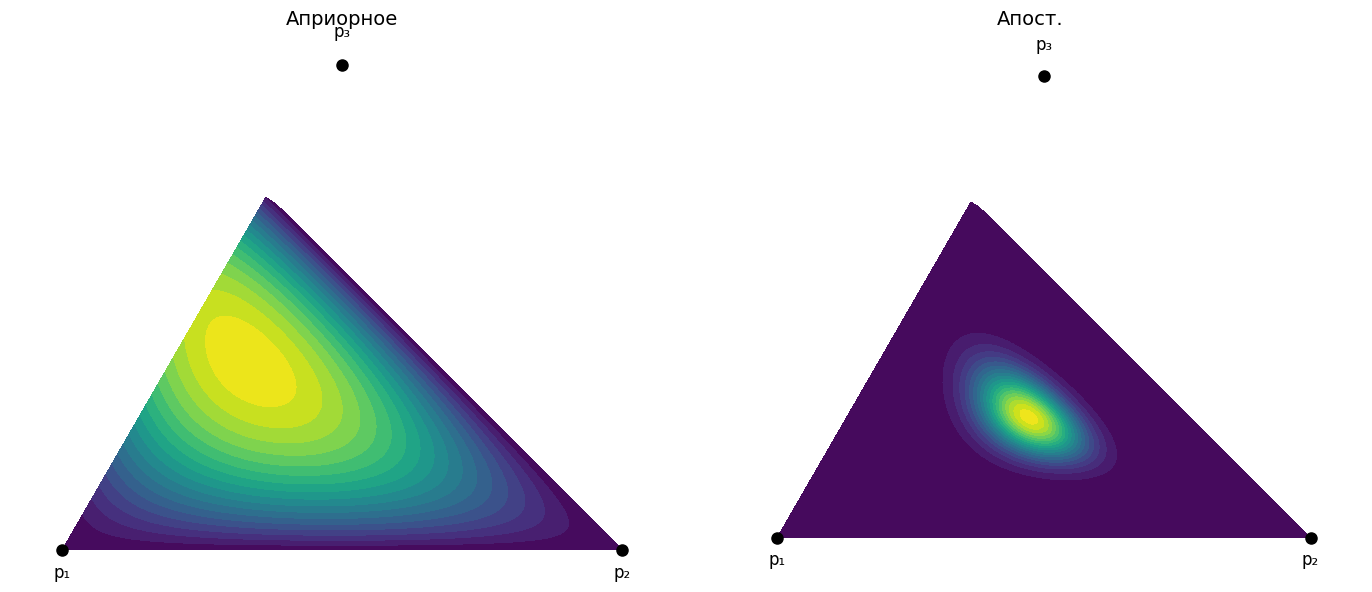

In [51]:
# Визуализация на симплексе (m=3)
def plot_dirichlet_simplex(alpha, title, ax):
    from scipy.special import gammaln
    
    corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3)/2]])
    triangle = tri.Triangulation(corners[:, 0], corners[:, 1])
    refiner = tri.UniformTriRefiner(triangle)
    trimesh = refiner.refine_triangulation(subdiv=7)
    
    p1, p2 = trimesh.x, trimesh.y
    p3 = 1 - p1 - p2
    mask = (p3 >= 0) & (p3 <= 1) & (p1 >= 0) & (p2 >= 0)
    
    # Нормализуем координаты
    p_coords = np.column_stack([p1[mask], p2[mask], p3[mask]])
    p_coords = p_coords / p_coords.sum(axis=1, keepdims=True)
    
    # Вычисляем плотность Дирихле вручную
    alpha_sum = np.sum(alpha)
    log_norm = gammaln(alpha_sum) - np.sum(gammaln(alpha))
    log_density = log_norm + np.sum((alpha - 1) * np.log(p_coords + 1e-10), axis=1)
    density = np.exp(log_density)
    
    # Фильтруем нефинитные значения
    valid_mask = np.isfinite(density) & (density > 0)
    valid_x = p1[mask][valid_mask]
    valid_y = p2[mask][valid_mask]
    valid_density = density[valid_mask]
    
    # Создаем новую триангуляцию только для валидных точек
    valid_tri = tri.Triangulation(valid_x, valid_y)
    
    ax.tricontourf(valid_tri, valid_density, levels=20, cmap='viridis')
    ax.plot(corners[:, 0], corners[:, 1], 'ko', markersize=8)
    ax.text(corners[0, 0], corners[0, 1]-0.05, 'p₁', ha='center', fontsize=12)
    ax.text(corners[1, 0], corners[1, 1]-0.05, 'p₂', ha='center', fontsize=12)
    ax.text(corners[2, 0], corners[2, 1]+0.05, 'p₃', ha='center', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.axis('equal')
    ax.axis('off')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_dirichlet_simplex(alpha_prior, 'Априорное', axes[0])
plot_dirichlet_simplex(alpha_post, 'Апост.', axes[1])
plt.tight_layout()
plt.show()


Априорное распределение размазано по симплексу, апост. концентрируется в области наблюденных данных

Сравниваем истинные вероятности, MLE и байесовские оценки на графике и в таблице.

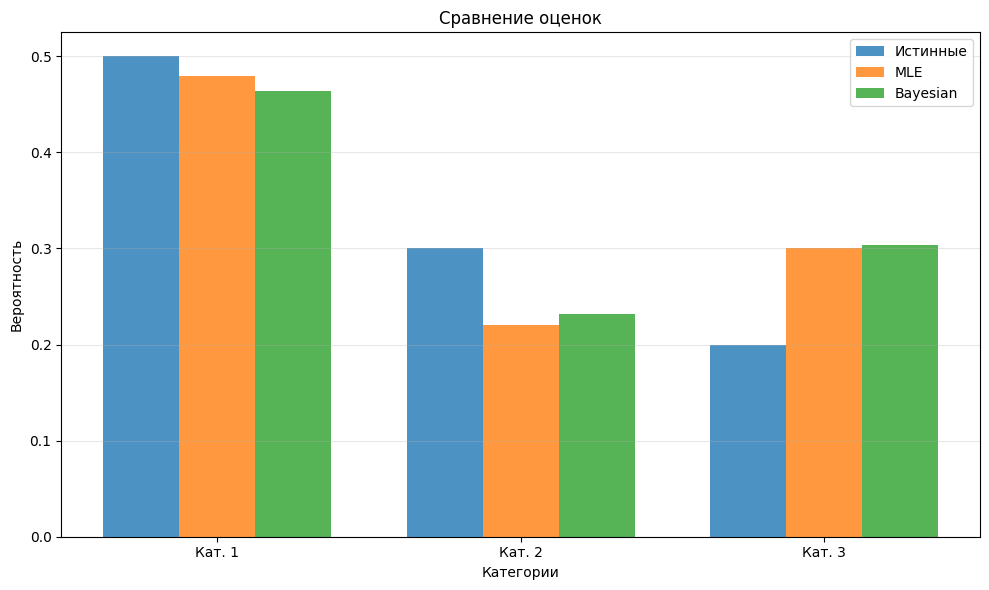


Сравнение:


,Категория,Истинная,MLE,Bayesian
0,Кат. 1,0.5,0.48,0.464286
1,Кат. 2,0.3,0.22,0.232143
2,Кат. 3,0.2,0.30,0.303571


In [52]:
# Сравнение оценок
import pandas as pd

categories = [f'Кат. {i+1}' for i in range(m)]
x = np.arange(len(categories))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, true_p, width, label='Истинные', alpha=0.8)
ax.bar(x, n_obs/n, width, label='MLE', alpha=0.8)
ax.bar(x + width, posterior_mean, width, label='Bayesian', alpha=0.8)

ax.set_xlabel('Категории')
ax.set_ylabel('Вероятность')
ax.set_title('Сравнение оценок')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Таблица сравнения
comparison_df = pd.DataFrame({
    'Категория': [f'Кат. {i+1}' for i in range(m)],
    'Истинная': true_p,
    'MLE': n_obs/n,
    'Bayesian': posterior_mean
})
print("\nСравнение:")
comparison_df


Байесовские оценки ближе к истинным, чем MLE, так как учитывают априорную информацию.